# Online Payment Fraud Detection - Model Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv('../artifacts/train.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,13,DEBIT,1735.17,C666076152,5016.00,3280.83,C850455959,175711.33,177446.50,0,0
1,19,CASH_OUT,134387.74,C1325443988,83831.00,0.00,C262756161,479308.86,565736.96,0,0
2,11,CASH_OUT,100041.57,C1651418178,154237.00,54195.43,C861057755,0.00,100041.57,0,0
3,18,PAYMENT,1918.83,C1524251578,380117.67,378198.84,M575336910,0.00,0.00,0,0
4,12,CASH_OUT,456760.59,C1434913388,5043.00,0.00,C1080593804,0.00,456760.59,0,0


## 2. Preprocessing
- Encode `type` column
- Drop `nameOrig`, `nameDest`, `isFlaggedFraud` (irrelevant for prediction)
- Split into X and y

In [3]:
# Encode Transaction Type
df['type'] = LabelEncoder().fit_transform(df['type'])

# Drop Columns
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

# Split Features and Target
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Model Training & Evaluation

In [5]:
def evaluate_model(model, name):
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n--- {name} Results ---")
    print(classification_report(y_test, y_pred))
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

### Logistic Regression

Training Logistic Regression...

--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    165097
           1       0.73      0.26      0.38       127

    accuracy                           1.00    165224
   macro avg       0.87      0.63      0.69    165224
weighted avg       1.00      1.00      1.00    165224

F1 Score: 0.3837


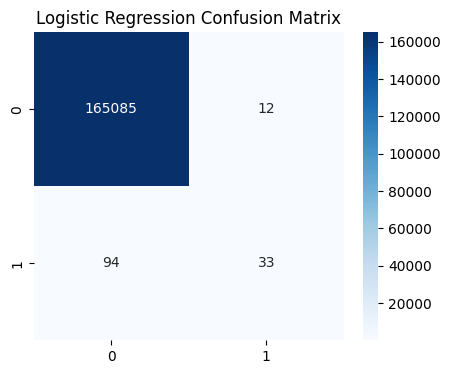

In [6]:
evaluate_model(LogisticRegression(max_iter=1000), "Logistic Regression")

### Random Forest

Training Random Forest...

--- Random Forest Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    165097
           1       0.99      0.73      0.84       127

    accuracy                           1.00    165224
   macro avg       0.99      0.87      0.92    165224
weighted avg       1.00      1.00      1.00    165224

F1 Score: 0.8416


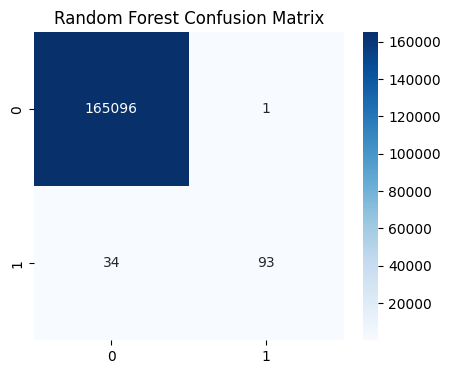

In [7]:
evaluate_model(RandomForestClassifier(n_estimators=50, random_state=42), "Random Forest")

### XGBoost

Training XGBoost...

--- XGBoost Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    165097
           1       0.79      0.83      0.81       127

    accuracy                           1.00    165224
   macro avg       0.89      0.91      0.90    165224
weighted avg       1.00      1.00      1.00    165224

F1 Score: 0.8077


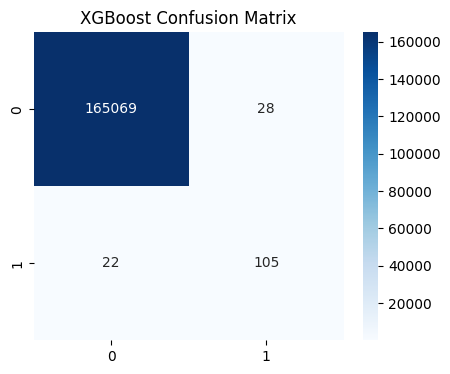

In [8]:
# scale_pos_weight deals with class imbalance (approx total / fraud)
evaluate_model(XGBClassifier(scale_pos_weight=100, eval_metric='logloss'), "XGBoost")